In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [18]:
# Import the dataset
df = pd.read_excel("ABS Tech Case 2026_Data.xlsx")

# Capitalize entries in column for hispanic/latino
df["HispanicLatino"] = df["HispanicLatino"].str.capitalize()

In [19]:
import pandas as pd
from scipy import stats
import numpy as np

df = pd.read_csv("Q4/abs_tech.csv")

# Identify the starting column
start_col = "EngagementSurvey"

# Get all columns from EngagementSurvey onward
cols = df.columns[df.columns.get_loc(start_col):]

# Remove 'Remote' because it is not numeric
cols = [c for c in cols if c != "Remote"]

# Keep only numeric columns
numeric_cols = df[cols].select_dtypes(include="number").columns.tolist()

# Create two groups
df["EmpGroup"] = df["EmploymentStatus"].apply(
    lambda x: "Active" if x == "Active" else
              "Voluntarily Terminated" if x == "Voluntarily Terminated" else None
)

df_filtered = df[df["EmpGroup"].isin(["Active", "Voluntarily Terminated"])]

active = df_filtered[df_filtered["EmpGroup"] == "Active"]
terminated = df_filtered[df_filtered["EmpGroup"] == "Voluntarily Terminated"]

# ---- Statistical comparison ----

results = []

for col in numeric_cols:
    a = active[col].dropna()
    t = terminated[col].dropna()

    # Means
    mean_a = a.mean()
    mean_t = t.mean()

    # Difference
    diff = mean_a - mean_t
    perc_diff = diff / mean_t * 100 if mean_t != 0 else np.nan

    # Welch t-test (unequal variances)
    t_stat, p_val = stats.ttest_ind(a, t, equal_var=False)

    # 95% CI for difference
    # Standard error
    se = np.sqrt(a.var(ddof=1)/len(a) + t.var(ddof=1)/len(t))
    df_welch = (a.var(ddof=1)/len(a) + t.var(ddof=1)/len(t))**2 / (
        (a.var(ddof=1)/len(a))**2/(len(a)-1) + (t.var(ddof=1)/len(t))**2/(len(t)-1)
    )
    ci_low = diff - stats.t.ppf(0.975, df_welch) * se
    ci_high = diff + stats.t.ppf(0.975, df_welch) * se

    results.append({
        "Metric": col,
        "Mean_Active": mean_a,
        "Mean_Terminated": mean_t,
        "Mean_Diff": diff,
        "Mean_%_Diff": perc_diff,
        "p_value": p_val,
        "CI_95_Low": ci_low,
        "CI_95_High": ci_high,
        "N_Active": len(a),
        "N_Terminated": len(t)
    })

final_stats = pd.DataFrame(results)

# Optional: sort by p-value ascending
final_stats = final_stats.sort_values("p_value")

print(final_stats)

                  Metric  Mean_Active  Mean_Terminated  Mean_Diff  \
13                CarOpp     2.864734         1.829545   1.035189   
12               OrgIden     3.000000         2.272727   0.727273   
9               ProjSelf     3.342995         2.488636   0.854359   
16                 Trust     3.381643         2.681818   0.699824   
8               ProjColl     3.135266         2.465909   0.669357   
11              TeamIden     3.458937         2.727273   0.731664   
10              ProjLead     3.178744         2.511364   0.667380   
19                AIConf     2.178744         1.568182   0.610562   
14               PsySafe     2.599034         2.000000   0.599034   
15              Feedback     3.338164         2.647727   0.690437   
17               Network     3.038647         2.579545   0.459102   
18                 AIUse     2.594203         2.113636   0.480567   
2   SpecialProjectsCount     1.463768         0.511364   0.952404   
6                TechLev     5.222

In [20]:
final_stats

,Metric,Mean_Active,Mean_Terminated,Mean_Diff,Mean_%_Diff,p_value,CI_95_Low,CI_95_High,N_Active,N_Terminated
13,CarOpp,2.864734,1.829545,1.035189,56.581751,1.872617e-15,0.799402,1.270976,207,88
12,OrgIden,3.000000,2.272727,0.727273,32.000000,2.510313e-12,0.536552,0.917994,207,88
9,ProjSelf,3.342995,2.488636,0.854359,34.330399,1.439697e-11,0.622834,1.085884,207,88
16,Trust,3.381643,2.681818,0.699824,26.095145,1.472010e-11,0.510100,0.889549,207,88
8,ProjColl,3.135266,2.465909,0.669357,27.144416,4.384813e-08,0.439473,0.899241,207,88
11,TeamIden,3.458937,2.727273,0.731664,26.827697,1.073083e-07,0.471904,0.991425,207,88
10,ProjLead,3.178744,2.511364,0.667380,26.574420,1.418527e-07,0.427656,0.907104,207,88
19,AIConf,2.178744,1.568182,0.610562,38.934398,3.345958e-07,0.382198,0.838926,207,88
14,PsySafe,2.599034,2.000000,0.599034,29.951691,6.594450e-07,0.370106,0.827962,207,88
15,Feedback,3.338164,2.647727,0.690437,26.076590,3.907942e-06,0.405089,0.975785,207,88


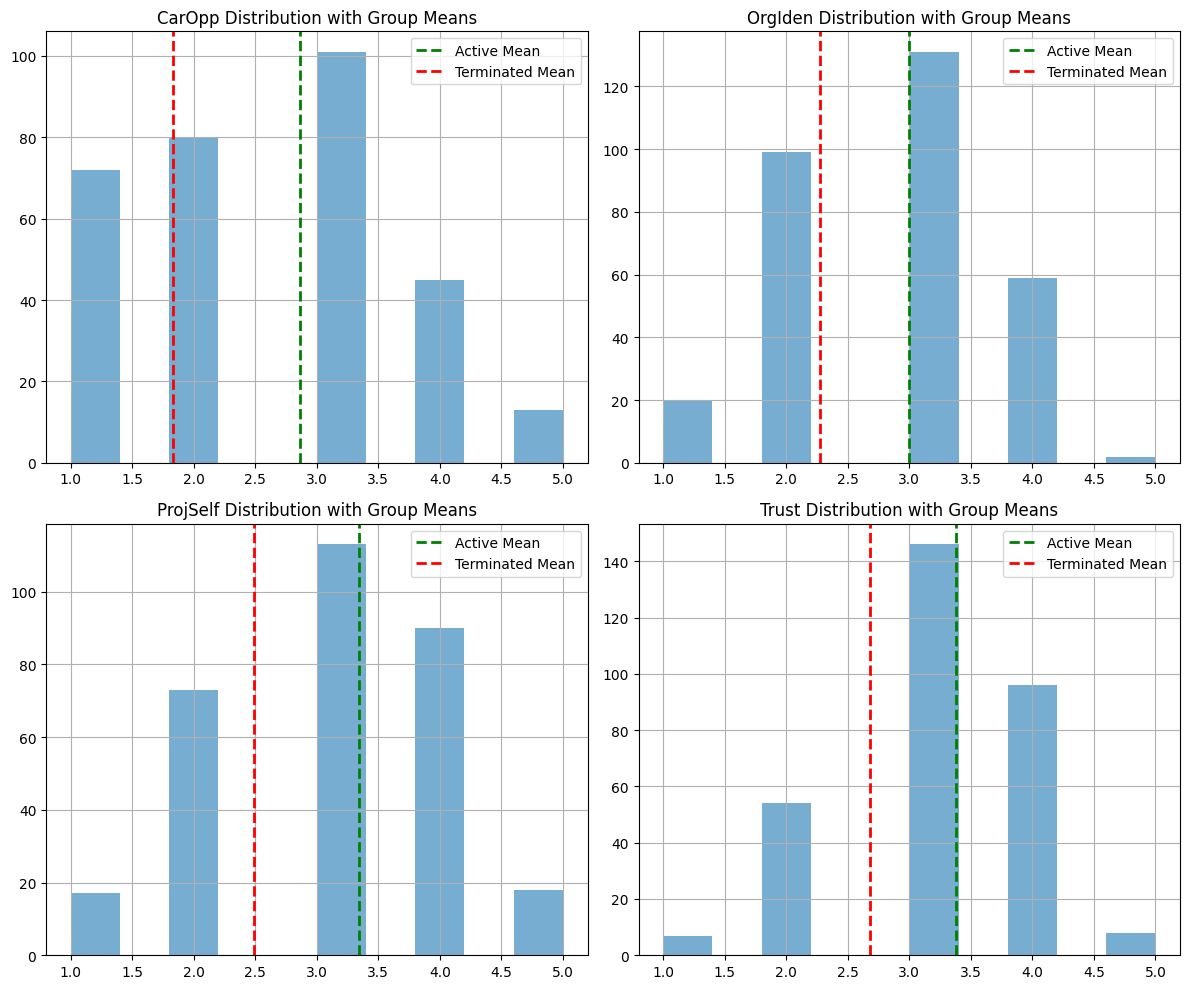

In [28]:
variables = ['CarOpp', 'OrgIden', 'ProjSelf', 'Trust']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, var in zip(axes, variables):
    df[var].hist(ax=ax, alpha=0.6)
    
    row = final_stats[final_stats['Metric'] == var].iloc[0]
    mean_active = row['Mean_Active']
    mean_terminated = row['Mean_Terminated']
    
    ax.axvline(mean_active, linestyle='--', linewidth=2, 
               label='Active Mean', color='green')
    ax.axvline(mean_terminated, linestyle='--', linewidth=2, 
               label='Terminated Mean', color='red')
    
    ax.set_title(f'{var} Distribution with Group Means')
    ax.legend()

plt.tight_layout()
plt.show()

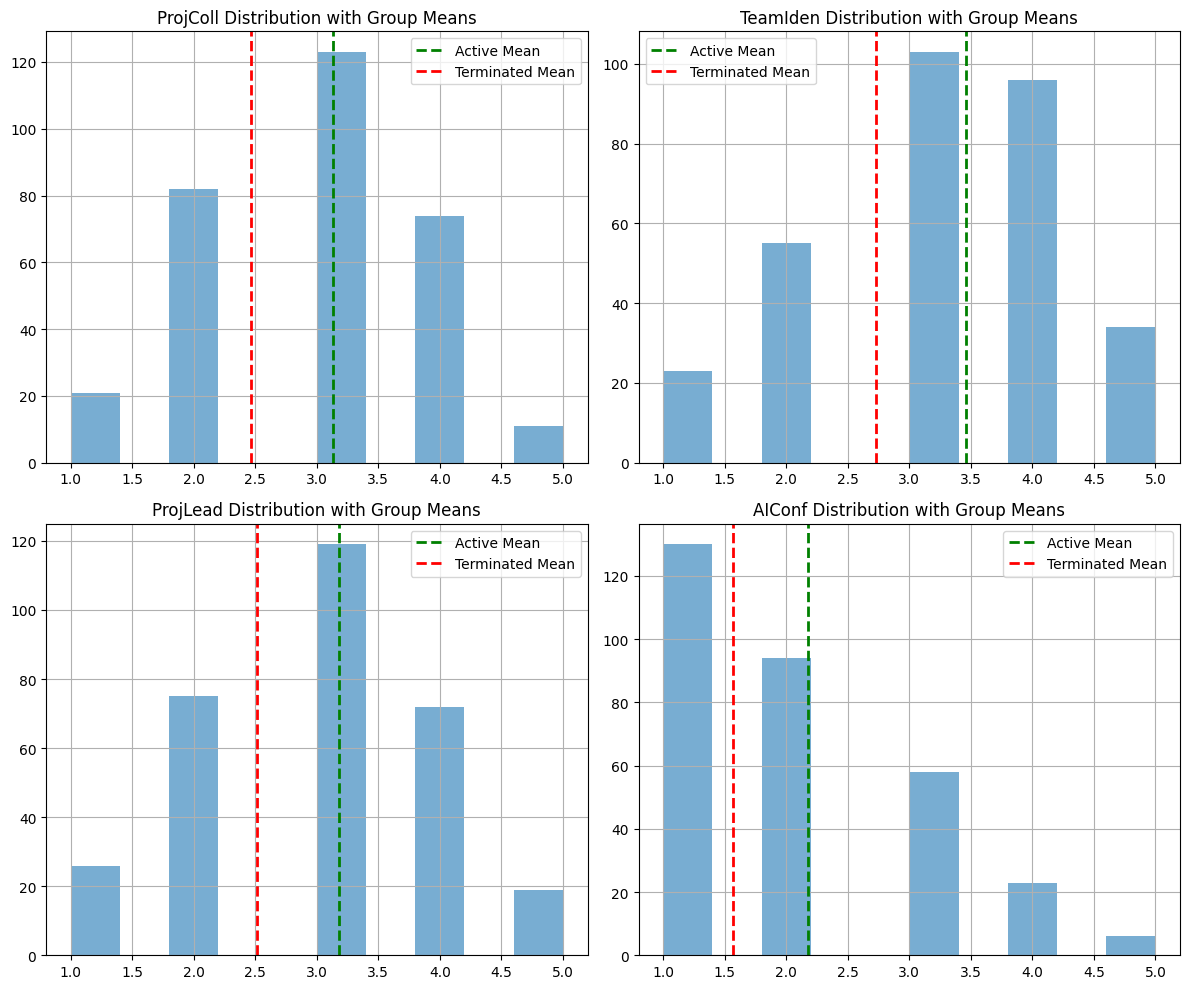

In [29]:
variables = ['ProjColl', 'TeamIden', 'ProjLead', 'AIConf']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, var in zip(axes, variables):
    df[var].hist(ax=ax, alpha=0.6)
    
    row = final_stats[final_stats['Metric'] == var].iloc[0]
    mean_active = row['Mean_Active']
    mean_terminated = row['Mean_Terminated']
    
    ax.axvline(mean_active, linestyle='--', linewidth=2, 
               label='Active Mean', color='green')
    ax.axvline(mean_terminated, linestyle='--', linewidth=2, 
               label='Terminated Mean', color='red')
    
    ax.set_title(f'{var} Distribution with Group Means')
    ax.legend()

plt.tight_layout()
plt.show()

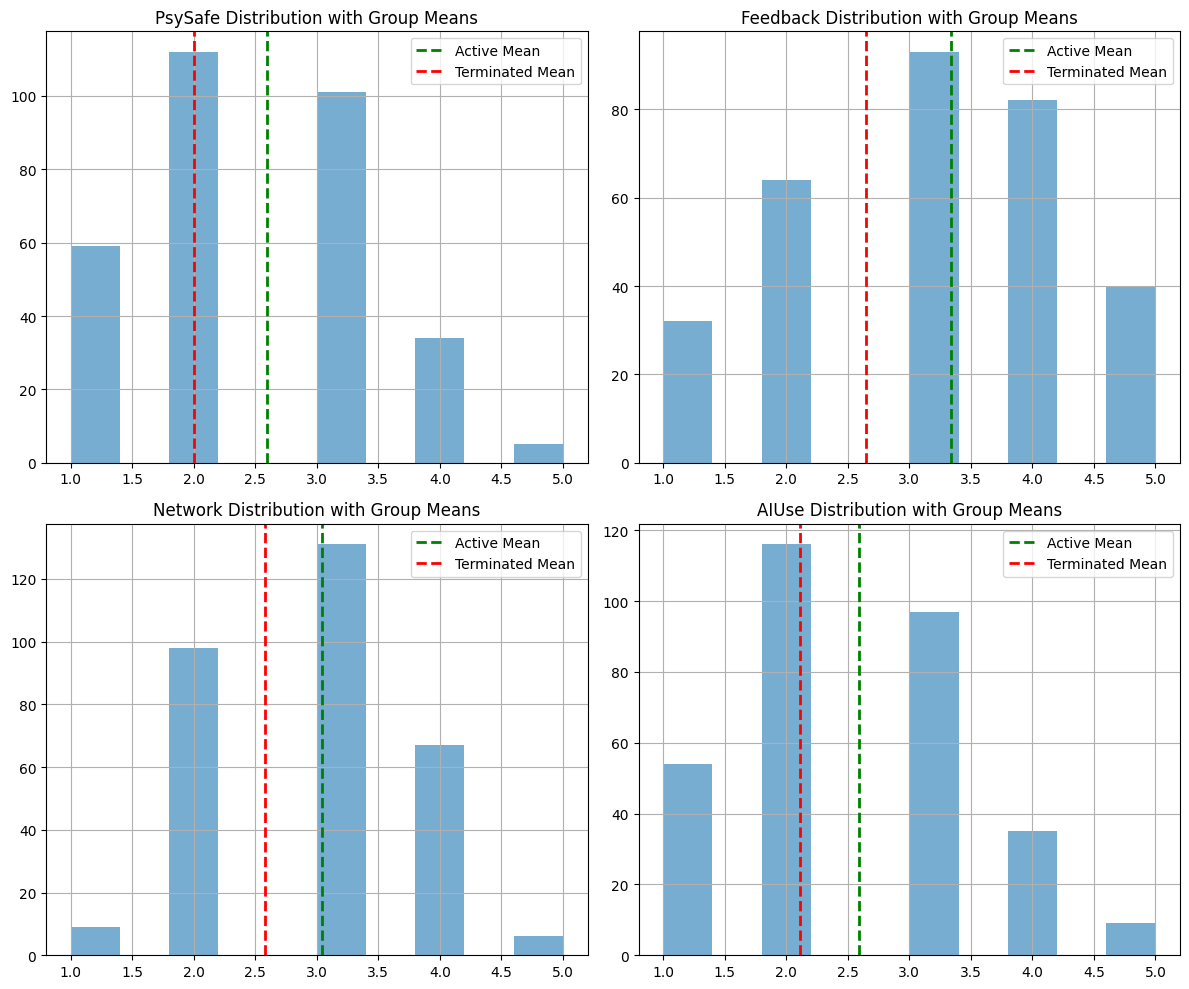

In [30]:
variables = ['PsySafe', 'Feedback', 'Network', 'AIUse']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, var in zip(axes, variables):
    df[var].hist(ax=ax, alpha=0.6)
    
    row = final_stats[final_stats['Metric'] == var].iloc[0]
    mean_active = row['Mean_Active']
    mean_terminated = row['Mean_Terminated']
    
    ax.axvline(mean_active, linestyle='--', linewidth=2, 
               label='Active Mean', color='green')
    ax.axvline(mean_terminated, linestyle='--', linewidth=2, 
               label='Terminated Mean', color='red')
    
    ax.set_title(f'{var} Distribution with Group Means')
    ax.legend()

plt.tight_layout()
plt.show()

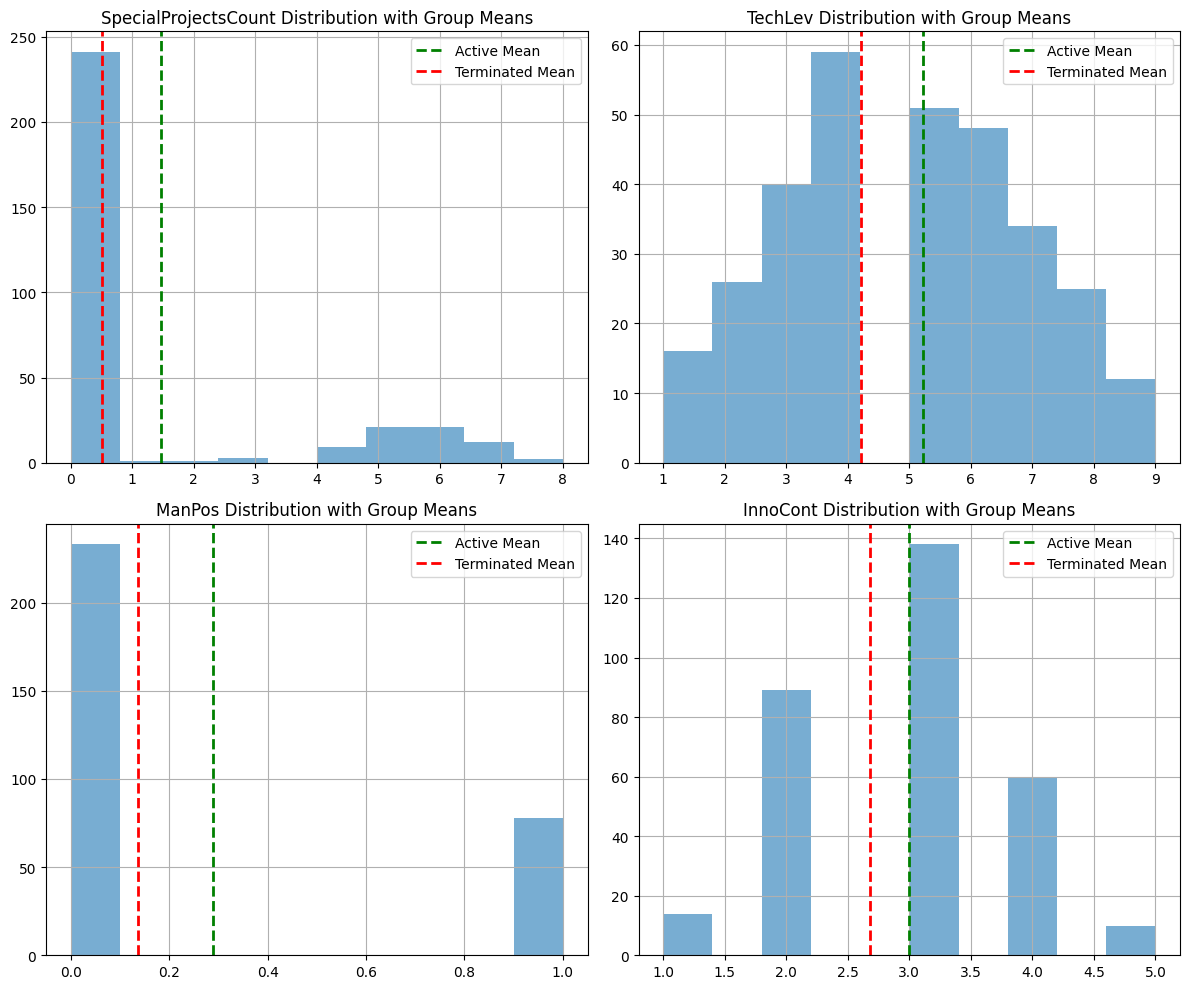

In [31]:
variables = ['SpecialProjectsCount', 'TechLev', 'ManPos', 'InnoCont']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, var in zip(axes, variables):
    df[var].hist(ax=ax, alpha=0.6)
    
    row = final_stats[final_stats['Metric'] == var].iloc[0]
    mean_active = row['Mean_Active']
    mean_terminated = row['Mean_Terminated']
    
    ax.axvline(mean_active, linestyle='--', linewidth=2, 
               label='Active Mean', color='green')
    ax.axvline(mean_terminated, linestyle='--', linewidth=2, 
               label='Terminated Mean', color='red')
    
    ax.set_title(f'{var} Distribution with Group Means')
    ax.legend()

plt.tight_layout()
plt.show()

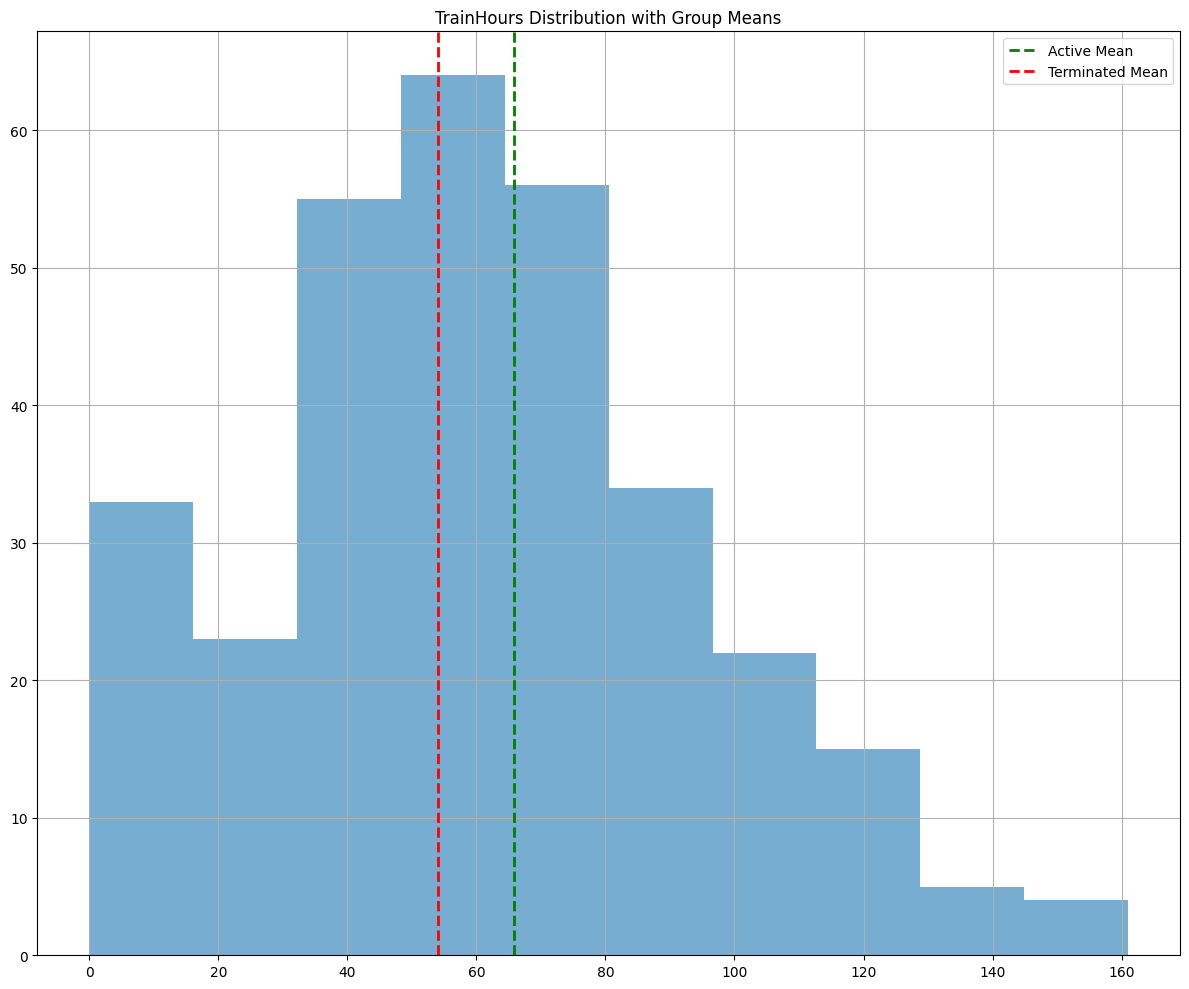

In [36]:
variables = ['TrainHours']

fig, axes = plt.subplots(1, 1, figsize=(12, 10))

for var in variables:
    df[var].hist(alpha=0.6)
    
    row = final_stats[final_stats['Metric'] == var].iloc[0]
    mean_active = row['Mean_Active']
    mean_terminated = row['Mean_Terminated']
    
    axes.axvline(mean_active, linestyle='--', linewidth=2, 
               label='Active Mean', color='green')
    axes.axvline(mean_terminated, linestyle='--', linewidth=2, 
               label='Terminated Mean', color='red')
    
    axes.set_title(f'{var} Distribution with Group Means')
    axes.legend()

plt.tight_layout()
plt.show()